# Predicting fan_speed and light_intensity using Naive Bayes

This notebook uses a Gaussian Naive Bayes Classifier to predict smart-room
actuator levels from sensor data collected by an ESP32 (IR-based occupancy
counter, PIR motion sensor, LDR, and DHT11 temperature/humidity sensor).

We are going to take the following approach:

1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem definition

In a statement,
> Given occupancy count, motion state, temperature, humidity, and light
> level readings from the room, can we predict the appropriate fan speed
> and light intensity level (0-4) automatically?

## 2. Data

The dataset is synthetically generated to mirror real ESP32 sensor readings:
IR-sensor-derived occupancy `count`, an air-quality `co2_level` sensor,
`ldr_value`, and DHT11 `temp`/`humidity`, with the two target levels
`fan_speed` and `light_intensity` (0-4) built from a noisy, non-trivial
combination of the inputs so the model has to actually learn the
relationship.

## 3. Evaluation

> If we can reach a reasonably high accuracy (and sensible confusion matrix)
> predicting both fan_speed and light_intensity, the model is good enough to
> deploy on the ESP32 -> MQTT -> actuator pipeline. This notebook mirrors the
> Decision Tree notebook so the two algorithms can be compared directly.

## 4. Features

**Data dictionary**

1. `count` - number of people currently in the room (derived from dual IR
   sensor sequence logic), range 0-20
2. `co2_level` - CO2 concentration in ppm, range 200-3000 (rises with
   occupancy and poor ventilation)
3. `ldr_value` - light reading from the LDR, range 0-1000
   (lower = darker room)
4. `temp` - temperature in °C from DHT11
5. `humidity` - relative humidity % from DHT11
6. `fan_speed` - target label, fan speed level 0-4 (predicted from `count`,
   `temp`, `humidity`, `co2_level`)
7. `light_intensity` - target label, light level 0-4 (predicted from `count`,
   `ldr_value`, `co2_level`)


# Preparing the tools

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import sklearn
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

## Load data

In [36]:
df = pd.read_csv("sensor_dataset.csv")
df.shape

(8000, 7)

## Data Exploration (EDA)

The goal here is to find out more about the data and become a subject
matter expert on the dataset we're working with.

1. What question(s) are we trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do we deal with it?
4. Where are the outliers and why should we care about them?
5. How can we add, change or remove features to get more out of the data?

In [37]:
df.head()

,count,co2_level,ldr_value,temp,humidity,fan_speed,light_intensity
0,17,2768,158,42.5,60.9,3,4
1,8,1427,63,31.4,69.2,2,3
2,6,1311,38,35.2,65.0,2,3
3,19,2956,337,30.4,63.2,3,4
4,7,1301,140,22.8,61.1,1,3


In [38]:
df.tail()

,count,co2_level,ldr_value,temp,humidity,fan_speed,light_intensity
7995,10,1523,103,15.6,52.7,1,3
7996,20,2959,305,27.4,58.5,2,4
7997,3,844,130,34.1,48.7,1,2
7998,7,1438,693,49.1,58.8,3,1
7999,5,896,878,13.0,69.0,1,1


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   count            8000 non-null   int64  
 1   co2_level        8000 non-null   int64  
 2   ldr_value        8000 non-null   int64  
 3   temp             8000 non-null   float64
 4   humidity         8000 non-null   float64
 5   fan_speed        8000 non-null   int64  
 6   light_intensity  8000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 437.6 KB


In [40]:
# Are there any missing values?
df.isna().sum()

count              0
co2_level          0
ldr_value          0
temp               0
humidity           0
fan_speed          0
light_intensity    0
dtype: int64

In [41]:
df.describe()

,count,co2_level,ldr_value,temp,humidity,fan_speed,light_intensity
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,10.054125,1699.781375,464.506875,33.030012,63.092538,1.981125,2.069750
std,6.074748,796.156479,312.244880,9.558642,9.609507,0.909463,1.148281
min,0.000000,200.000000,0.000000,13.000000,43.000000,0.000000,0.000000
25%,5.000000,1007.000000,123.000000,26.200000,56.100000,1.000000,1.000000
50%,10.000000,1718.000000,452.000000,33.000000,63.100000,2.000000,2.000000
75%,15.000000,2386.250000,763.000000,39.700000,69.900000,3.000000,3.000000
max,20.000000,3000.000000,1000.000000,53.000000,83.000000,4.000000,4.000000


## fan_speed and light_intensity distribution

In [42]:
df.fan_speed.value_counts().sort_index()

fan_speed
0     509
1    1626
2    3604
3    2029
4     232
Name: count, dtype: int64

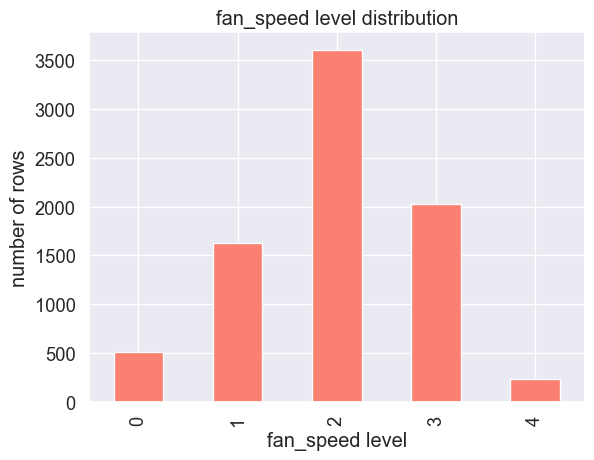

In [43]:
df.fan_speed.value_counts().sort_index().plot(kind="bar", color="salmon")
plt.title("fan_speed level distribution")
plt.xlabel("fan_speed level")
plt.ylabel("number of rows");

In [44]:
df.light_intensity.value_counts().sort_index()

light_intensity
0     843
1    1595
2    2613
3    2059
4     890
Name: count, dtype: int64

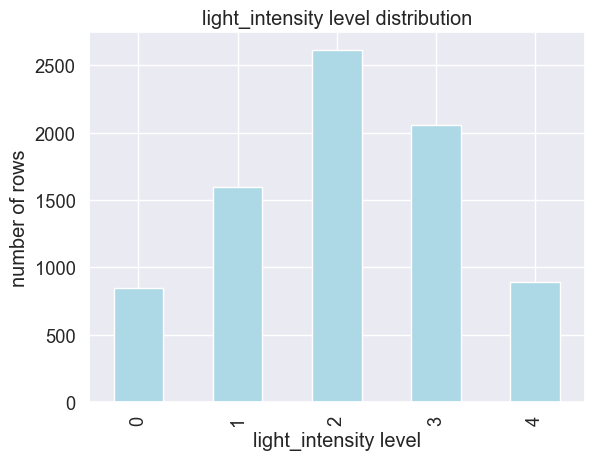

In [45]:
df.light_intensity.value_counts().sort_index().plot(kind="bar", color="lightblue")
plt.title("light_intensity level distribution")
plt.xlabel("light_intensity level")
plt.ylabel("number of rows");

## fan_speed vs co2_level

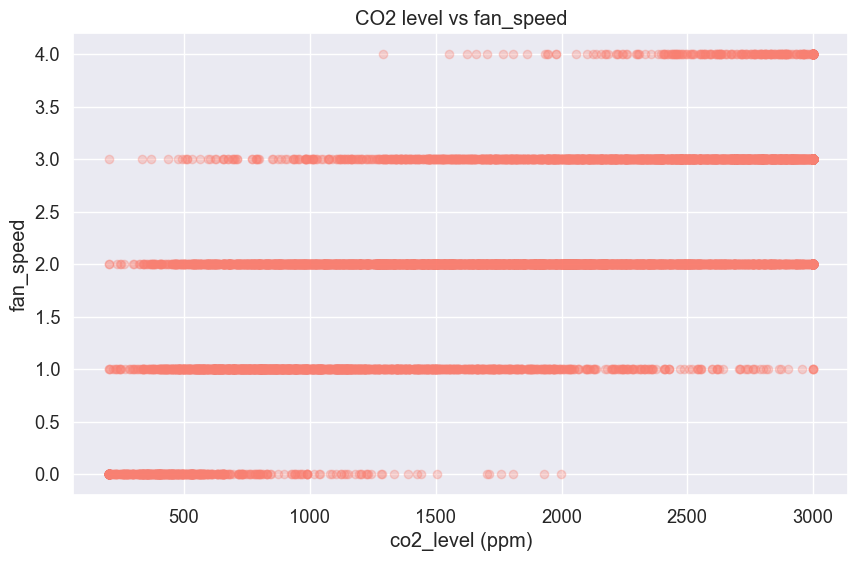

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(df["co2_level"], df["fan_speed"], c="salmon", alpha=0.3)
plt.title("CO2 level vs fan_speed")
plt.xlabel("co2_level (ppm)")
plt.ylabel("fan_speed");

## count vs fan_speed and light_intensity

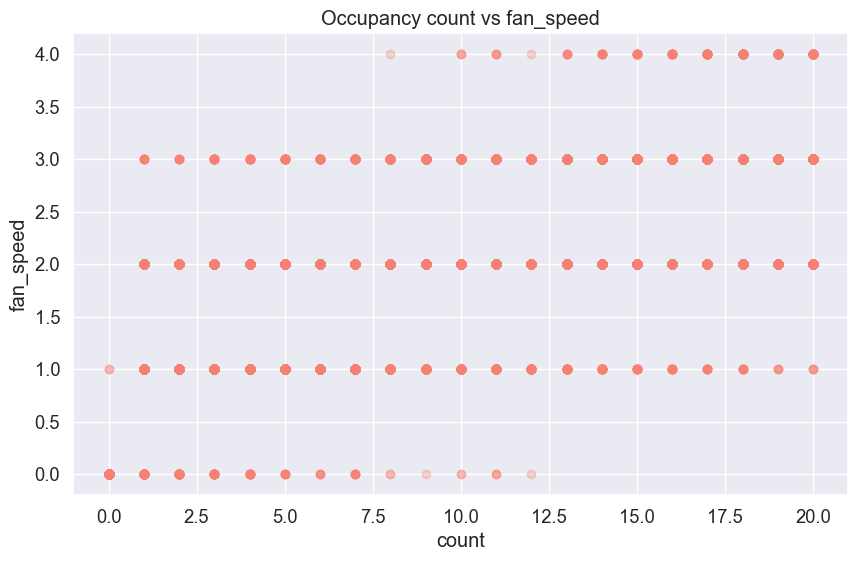

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(df["count"], df["fan_speed"], c="salmon", alpha=0.3)
plt.title("Occupancy count vs fan_speed")
plt.xlabel("count")
plt.ylabel("fan_speed");

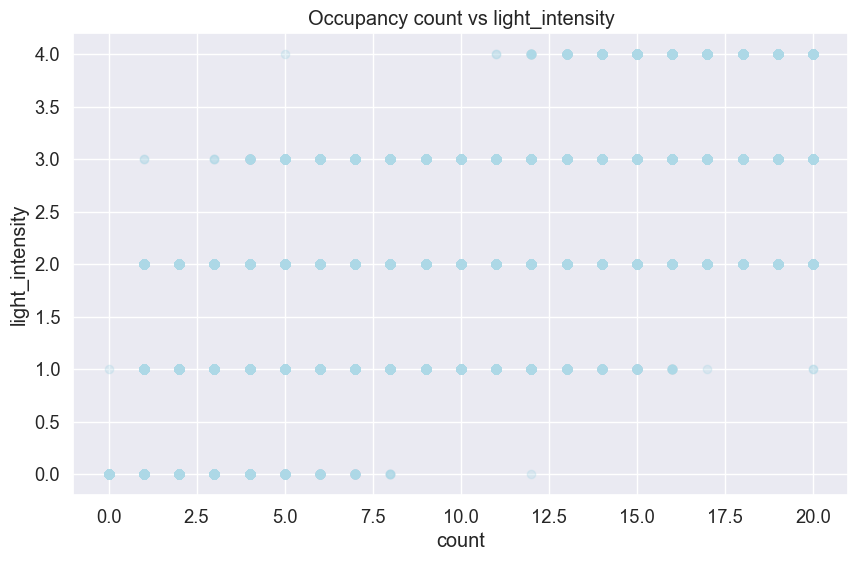

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(df["count"], df["light_intensity"], c="lightblue", alpha=0.3)
plt.title("Occupancy count vs light_intensity")
plt.xlabel("count")
plt.ylabel("light_intensity");

## Correlation

How strongly does each input feature relate to each target?

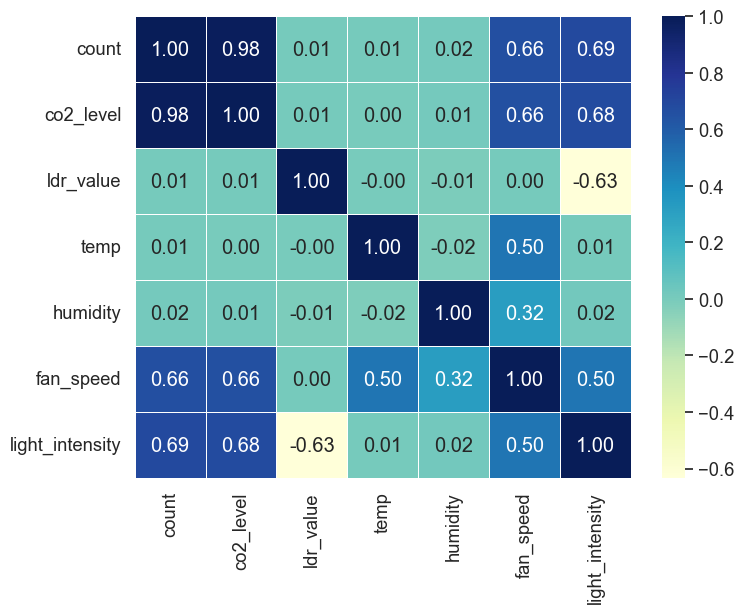

In [49]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.heatmap(corr_matrix,
                  annot=True,
                  linewidths=0.5,
                  fmt=".2f",
                  cmap="YlGnBu");

## Why Gaussian Naive Bayes

Naive Bayes assumes every feature is conditionally independent given the
class, and (in the Gaussian variant) that each feature is normally
distributed within each class. Our features are continuous (`count`,
`temp`, `humidity`, `ldr_value`, `co2_level`), which is what
`GaussianNB` is built for - it estimates a mean and variance per feature,
per class, from the training data, then classifies new points by whichever
class has the highest posterior probability.

This is a much simpler model than a Decision Tree - it doesn't capture
feature interactions (e.g. "high temp AND high count") directly, only each
feature's individual contribution, so we'd expect it to do reasonably well
here but likely underperform the Decision Tree on accuracy.

# 5. Modelling - fan_speed

In [50]:
df.head()

,count,co2_level,ldr_value,temp,humidity,fan_speed,light_intensity
0,17,2768,158,42.5,60.9,3,4
1,8,1427,63,31.4,69.2,2,3
2,6,1311,38,35.2,65.0,2,3
3,19,2956,337,30.4,63.2,3,4
4,7,1301,140,22.8,61.1,1,3


In [51]:
# Split data into X and y for fan_speed
X_fan = df[["count", "co2_level", "temp", "humidity"]]
y_fan = df["fan_speed"]

In [52]:
X_fan.head()

,count,co2_level,temp,humidity
0,17,2768,42.5,60.9
1,8,1427,31.4,69.2
2,6,1311,35.2,65.0
3,19,2956,30.4,63.2
4,7,1301,22.8,61.1


In [53]:
y_fan.head()

0    3
1    2
2    2
3    3
4    1
Name: fan_speed, dtype: int64

In [54]:
# split data into train and test sets
np.random.seed(42)

X_train_fan, X_test_fan, y_train_fan, y_test_fan = train_test_split(X_fan,
                                                                      y_fan,
                                                                      test_size=0.2)

In [55]:
X_train_fan.shape, X_test_fan.shape

((6400, 4), (1600, 4))

* We will find the patterns on the training set.
* We will use those patterns on the test set.
* Baseline model: a default `GaussianNB` with no tuning.

In [56]:
# Baseline Naive Bayes for fan_speed
np.random.seed(42)

nb_fan_baseline = GaussianNB()
nb_fan_baseline.fit(X_train_fan, y_train_fan)
baseline_fan_score = nb_fan_baseline.score(X_test_fan, y_test_fan)
print(f"Baseline Naive Bayes accuracy (fan_speed): {baseline_fan_score * 100:.2f}%")

Baseline Naive Bayes accuracy (fan_speed): 69.56%


## Hyperparameter tuning with GridSearchCV (fan_speed)

`GaussianNB` has one real tunable hyperparameter: `var_smoothing`, a tiny
value added to every feature's variance to avoid numerical issues when a
class's feature values have very little spread. We search across a range
of values on a log scale, same as we'd tune `max_depth` for a tree.

In [57]:
nb_grid = {"var_smoothing": np.logspace(0, -12, num=25)}

np.random.seed(42)

gs_nb_fan = GridSearchCV(GaussianNB(),
                          param_grid=nb_grid,
                          cv=5,
                          verbose=1,
                          n_jobs=-1)

gs_nb_fan.fit(X_train_fan, y_train_fan)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-12])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [58]:
# check best hyperparameters
gs_nb_fan.best_params_

{'var_smoothing': np.float64(3.1622776601683795e-05)}

In [59]:
# evaluate the tuned model
gs_nb_fan.score(X_test_fan, y_test_fan)

0.71375

## Evaluating the tuned fan_speed classifier

* Confusion matrix
* Classification report

In [60]:
y_preds_fan = gs_nb_fan.predict(X_test_fan)
y_preds_fan

array([0, 3, 3, ..., 3, 2, 2], shape=(1600,))

In [61]:
# confusion matrix
print(confusion_matrix(y_test_fan, y_preds_fan))

[[ 93  13   1   0   0]
 [ 63 196  82   0   0]
 [ 70  37 550  60   0]
 [  5   0  86 295   0]
 [  0   0   1  40   8]]


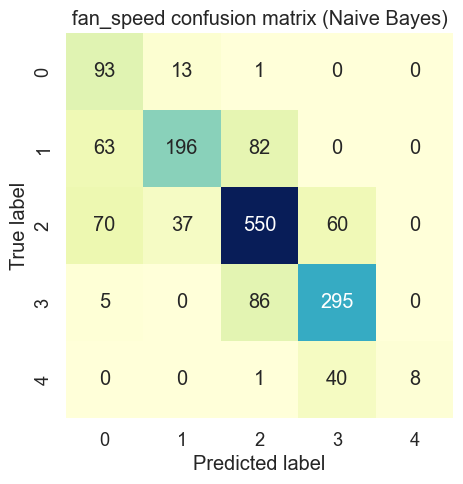

In [62]:
sns.set(font_scale=1.2)

def plot_conf_mat(y_test, y_preds, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                      annot=True,
                      fmt="d",
                      cbar=False,
                      cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plot_conf_mat(y_test_fan, y_preds_fan, "fan_speed confusion matrix (Naive Bayes)")

In [63]:
print(classification_report(y_test_fan, y_preds_fan))

              precision    recall  f1-score   support

           0       0.40      0.87      0.55       107
           1       0.80      0.57      0.67       341
           2       0.76      0.77      0.77       717
           3       0.75      0.76      0.76       386
           4       1.00      0.16      0.28        49

    accuracy                           0.71      1600
   macro avg       0.74      0.63      0.60      1600
weighted avg       0.75      0.71      0.71      1600



# calculate evaluation metrics using cross validation

* use `cross_val_score()`

In [64]:
# check best hyperparameters again
gs_nb_fan.best_params_

{'var_smoothing': np.float64(3.1622776601683795e-05)}

In [65]:
# create a fresh classifier with the best params found
best_nb_fan = GaussianNB(**gs_nb_fan.best_params_)

# cross validated accuracy
cv_acc_fan = cross_val_score(best_nb_fan,
                              X_fan,
                              y_fan,
                              cv=5,
                              scoring="accuracy")
cv_acc_fan

array([0.703125, 0.688125, 0.7075  , 0.725625, 0.725625])

In [66]:
cv_acc_fan_mean = cv_acc_fan.mean()
print(f"Cross-validated accuracy (fan_speed): {cv_acc_fan_mean * 100:.2f}%")

Cross-validated accuracy (fan_speed): 71.00%


## Per-class feature statistics (fan_speed)

Unlike a Decision Tree, Naive Bayes doesn't have a `feature_importances_`
attribute - instead it learns a mean and variance per feature, per class.
Looking at how far apart the class means are (relative to their spread)
is the NB equivalent of "how much does this feature matter" - features
whose class means are clearly separated drive the classification more.

In [67]:
best_nb_fan.fit(X_train_fan, y_train_fan)

fan_class_means = pd.DataFrame(best_nb_fan.theta_,
                                columns=X_fan.columns,
                                index=[f"fan_speed={c}" for c in best_nb_fan.classes_])
fan_class_means

,count,co2_level,temp,humidity
fan_speed=0,0.962687,523.097015,28.377612,59.592040
fan_speed=1,5.651362,1120.340856,25.808482,58.890195
fan_speed=2,10.372359,1742.611708,32.263007,62.856391
fan_speed=3,14.626293,2292.054778,39.356178,66.803469
fan_speed=4,17.759563,2697.322404,47.155738,71.987432


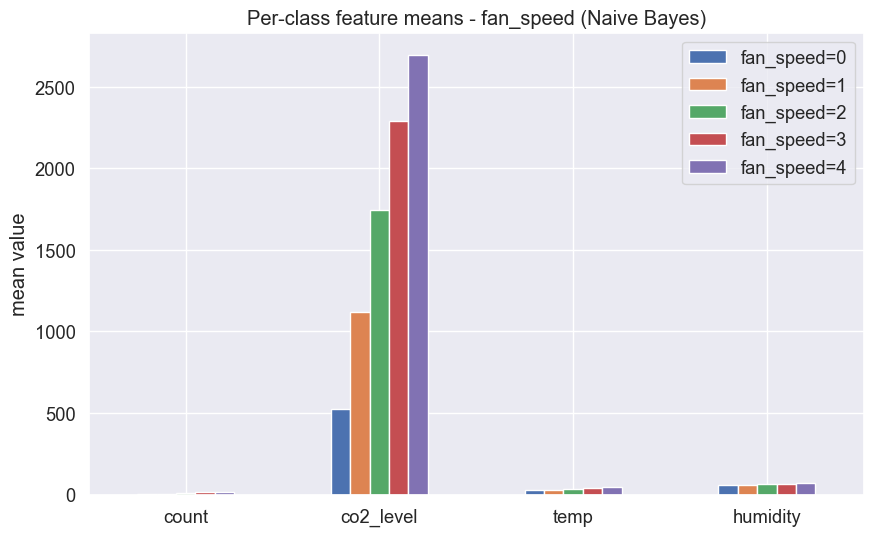

In [68]:
fan_class_means.T.plot.bar(figsize=(10, 6), title="Per-class feature means - fan_speed (Naive Bayes)")
plt.ylabel("mean value")
plt.xticks(rotation=0);

# 5b. Modelling - light_intensity

In [69]:
# Split data into X and y for light_intensity
X_light = df[["count", "co2_level", "ldr_value"]]
y_light = df["light_intensity"]

In [70]:
np.random.seed(42)

X_train_light, X_test_light, y_train_light, y_test_light = train_test_split(X_light,
                                                                              y_light,
                                                                              test_size=0.2)
X_train_light.shape, X_test_light.shape

((6400, 3), (1600, 3))

In [71]:
# Baseline Naive Bayes for light_intensity
np.random.seed(42)

nb_light_baseline = GaussianNB()
nb_light_baseline.fit(X_train_light, y_train_light)
baseline_light_score = nb_light_baseline.score(X_test_light, y_test_light)
print(f"Baseline Naive Bayes accuracy (light_intensity): {baseline_light_score * 100:.2f}%")

Baseline Naive Bayes accuracy (light_intensity): 68.75%


## Hyperparameter tuning with GridSearchCV (light_intensity)

In [72]:
np.random.seed(42)

gs_nb_light = GridSearchCV(GaussianNB(),
                            param_grid=nb_grid,
                            cv=5,
                            verbose=1,
                            n_jobs=-1)

gs_nb_light.fit(X_train_light, y_train_light)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-12])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [73]:
gs_nb_light.best_params_

{'var_smoothing': np.float64(0.00031622776601683794)}

In [74]:
gs_nb_light.score(X_test_light, y_test_light)

0.753125

## Evaluating the tuned light_intensity classifier

In [75]:
y_preds_light = gs_nb_light.predict(X_test_light)

print(confusion_matrix(y_test_light, y_preds_light))

[[140  35   2   0   0]
 [ 87 189  74   0   0]
 [ 38  14 410  34   0]
 [  0   0  70 315  10]
 [  0   0   1  30 151]]


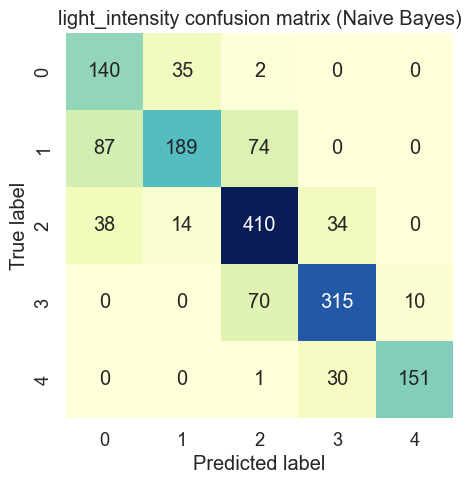

In [76]:
plot_conf_mat(y_test_light, y_preds_light, "light_intensity confusion matrix (Naive Bayes)")

In [77]:
print(classification_report(y_test_light, y_preds_light))

              precision    recall  f1-score   support

           0       0.53      0.79      0.63       177
           1       0.79      0.54      0.64       350
           2       0.74      0.83      0.78       496
           3       0.83      0.80      0.81       395
           4       0.94      0.83      0.88       182

    accuracy                           0.75      1600
   macro avg       0.77      0.76      0.75      1600
weighted avg       0.77      0.75      0.75      1600



In [78]:
best_nb_light = GaussianNB(**gs_nb_light.best_params_)

cv_acc_light = cross_val_score(best_nb_light,
                                X_light,
                                y_light,
                                cv=5,
                                scoring="accuracy")
cv_acc_light_mean = cv_acc_light.mean()
print(f"Cross-validated accuracy (light_intensity): {cv_acc_light_mean * 100:.2f}%")

Cross-validated accuracy (light_intensity): 75.38%


## Per-class feature statistics (light_intensity)

In [79]:
best_nb_light.fit(X_train_light, y_train_light)

light_class_means = pd.DataFrame(best_nb_light.theta_,
                                  columns=X_light.columns,
                                  index=[f"light_intensity={c}" for c in best_nb_light.classes_])
light_class_means

,count,co2_level,ldr_value
light_intensity=0,1.762763,619.725225,709.352853
light_intensity=1,6.679518,1256.652209,717.869076
light_intensity=2,10.086443,1705.485593,505.708550
light_intensity=3,13.156851,2102.737981,278.644231
light_intensity=4,17.145480,2618.024011,106.929379


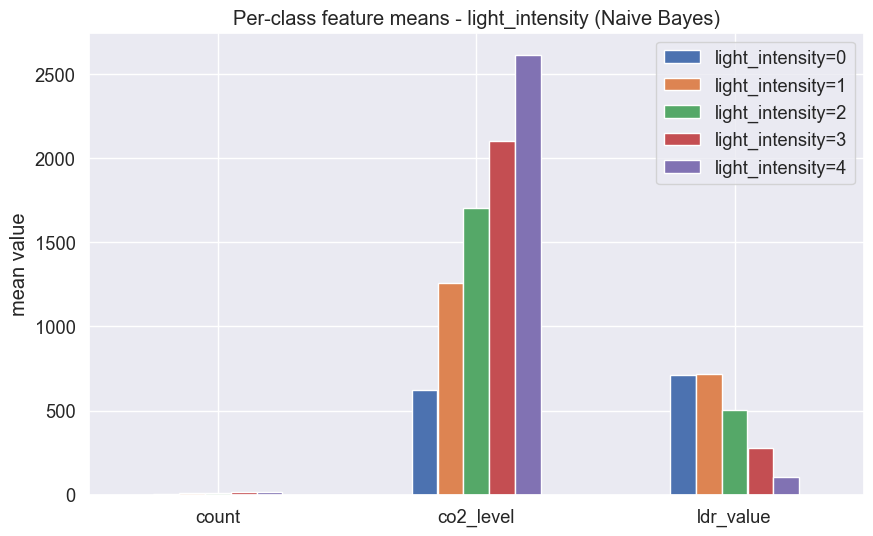

In [80]:
light_class_means.T.plot.bar(figsize=(10, 6), title="Per-class feature means - light_intensity (Naive Bayes)")
plt.ylabel("mean value")
plt.xticks(rotation=0);

## Model comparison summary

In [81]:
model_compare = pd.DataFrame({
    "fan_speed": [baseline_fan_score, gs_nb_fan.score(X_test_fan, y_test_fan), cv_acc_fan_mean],
    "light_intensity": [baseline_light_score, gs_nb_light.score(X_test_light, y_test_light), cv_acc_light_mean]
}, index=["baseline (untuned)", "tuned (GridSearchCV)", "cross-validated"])

model_compare

,fan_speed,light_intensity
baseline (untuned),0.695625,0.687500
tuned (GridSearchCV),0.713750,0.753125
cross-validated,0.710000,0.753750


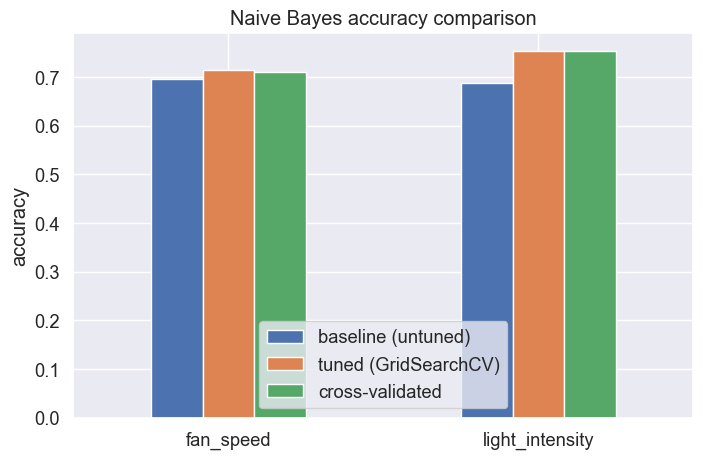

In [82]:
model_compare.T.plot.bar(figsize=(8, 5), title="Naive Bayes accuracy comparison")
plt.ylabel("accuracy")
plt.xticks(rotation=0);

In [84]:
import time
import pickle
import sys
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(model, model_name, X_test, y_test, target_name):
    y_pred = model.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="macro", zero_division=0)

    single_sample = X_test.iloc[[0]]
    n_runs = 200
    for _ in range(5):
        model.predict(single_sample)
    start = time.perf_counter()
    for _ in range(n_runs):
        model.predict(single_sample)
    end = time.perf_counter()
    response_time_ms = ((end - start) / n_runs) * 1000

    model_size_kb = sys.getsizeof(pickle.dumps(model)) / 1024
    energy_uj = 0.528 * (response_time_ms / 1000) * 1e6  # assumes ~0.528W ESP32 active power

    print(f"--- Naive Bayes ({target_name}) ---")
    print(f"Accuracy       : {accuracy*100:.2f}%")
    print(f"Precision      : {precision*100:.2f}%")
    print(f"Recall         : {recall*100:.2f}%")
    print(f"F1 Score       : {f1*100:.2f}%")
    print(f"Response Time  : {response_time_ms:.4f} ms")
    print(f"Model Size     : {model_size_kb:.2f} KB")
    print(f"Energy Estimate: {energy_uj:.2f} uJ")
    print()

get_metrics(best_nb_fan, "Naive Bayes", X_test_fan, y_test_fan, "fan_speed")
get_metrics(best_nb_light, "Naive Bayes", X_test_light, y_test_light, "light_intensity")

--- Naive Bayes (fan_speed) ---
Accuracy       : 71.38%
Precision      : 74.20%
Recall         : 62.77%
F1 Score       : 60.39%
Response Time  : 0.5799 ms
Model Size     : 1.11 KB
Energy Estimate: 306.17 uJ

--- Naive Bayes (light_intensity) ---
Accuracy       : 75.31%
Precision      : 76.55%
Recall         : 75.69%
F1 Score       : 74.99%
Response Time  : 0.4564 ms
Model Size     : 1.03 KB
Energy Estimate: 240.98 uJ

